**Homomorphic Filtering**

**Images:** `einstein.png` (primary), `highlights_and_shadows.jpg` (secondary)

## (a) Significance of the Multiplicative Model

### Significance for image processing

The multiplicative model has important implications:

1. **Non-uniform illumination cannot be removed by simple subtraction** — since
   illumination multiplies the signal, subtracting a constant does not help.

2. **The model is separable in the log domain** — taking the logarithm converts
   the product into a sum, enabling separate processing of each component.

3. **Reflectance is what we care about** — it encodes the true object properties.
   Illumination is a nuisance that distorts our perception of reflectance.

4. **Practical relevance** — outdoor images under variable cloud cover, medical
   images with uneven staining, and portraits with non-uniform studio lighting
   all follow this model.


## (b) Logarithmic Separation of Illumination and Reflectance


### Why this enables separation

Since $i(x,y)$ is **slowly varying** (low spatial frequency) and $r(x,y)$
captures **rapid changes** (high spatial frequency):

- $z_i = \ln i$ → concentrated in **low-frequency** region of the Fourier spectrum
- $z_r = \ln r$ → concentrated in **high-frequency** region of the Fourier spectrum

A **high-emphasis filter** in the frequency domain can:
- **Attenuate** $z_i$ (reduce non-uniform illumination)
- **Enhance** $z_r$ (sharpen reflectance / fine detail)

After filtering and inverse log (exponential) transform, the result has
corrected illumination while preserving or enhancing object detail.

## (c) Homomorphic Filtering Algorithm

### Pseudo-code

```
INPUT:  f(x,y)  — grayscale image with non-uniform illumination
PARAMS: sigma_s — filter bandwidth (controls LF/HF transition)
        gamma_L — gain for low frequencies  (< 1 to suppress illumination)
        gamma_H — gain for high frequencies (> 1 to enhance reflectance)

STEP 1 — Log transform
    z(x,y) = log(1 + f(x,y))

STEP 2 — Fourier Transform
    Z(u,v) = FFT2D{ z(x,y) }

STEP 3 — High-emphasis filter in frequency domain
    For each frequency (u,v):
        D(u,v)  = sqrt((u - M/2)^2 + (v - N/2)^2)   [distance from center]
        H(u,v)  = (gamma_H - gamma_L) * [1 - exp(-D^2 / (2*sigma_s^2))] + gamma_L

    Note: H ranges from gamma_L (DC, low freq) to gamma_H (high freq)
          gamma_L < 1  reduces illumination
          gamma_H > 1  boosts reflectance

STEP 4 — Apply filter
    Z_f(u,v) = H(u,v) * Z(u,v)

STEP 5 — Inverse Fourier Transform
    z_f(x,y) = Re{ IFFT2D{ Z_f(u,v) } }

STEP 6 — Inverse log (exponential transform)
    g(x,y) = exp(z_f(x,y)) - 1

STEP 7 — Normalize to [0, 255]
    output = normalize(g) to uint8

OUTPUT: g(x,y) — illumination-corrected image
```

## (d) Homomorphic Filtering vs Histogram Equalization

### When to prefer homomorphic filtering

1. **Medical imaging** — MRI, CT, histology slides with uneven staining or
   coil sensitivity — where the physical multiplicative model holds strictly.

2. **Outdoor photography** — images with strong shadows and bright highlights
   (e.g. backlit scenes) where global HE would over-brighten shadows and
   over-darken highlights simultaneously.

3. **Document scanning** — uneven illumination across a scanned page where
   histogram equalization would distort the ink-to-paper contrast.

4. **When edge sharpening is desired alongside illumination correction** —
   the high-emphasis filter simultaneously corrects illumination and enhances detail.

### When histogram equalization is preferred

HE is preferred for simple global contrast enhancement where a physical model
is not required, or when computational efficiency matters (e.g. real-time systems).


In [17]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('../outputs/q11_q12', exist_ok=True)

def homomorphic_filter(image, sigma_s=30, gamma_L=0.5, gamma_H=2.0, c=1.0):
    """
    Apply homomorphic filtering to a grayscale image.

    Algorithm:
        1. Log transform:      z   = log(1 + f)
        2. FFT:                Z   = FFT2D(z)
        3. High-emphasis filter:
           H(u,v) = (gamma_H - gamma_L) * [1 - exp(-D^2 / (2*sigma_s^2))] + gamma_L
        4. Filter application: Z_f = H * Z
        5. IFFT:               z_f = Re{IFFT2D(Z_f)}
        6. Exp transform:      g   = exp(z_f) - 1
        7. Normalize to [0, 255]

    Parameters:
        image   : uint8 grayscale image
        sigma_s : filter bandwidth — controls LF/HF transition
        gamma_L : low-frequency gain  (< 1 suppresses illumination)
        gamma_H : high-frequency gain (> 1 boosts reflectance / detail)
        c       : sharpness of filter transition

    Returns:
        result : uint8 filtered image
        H      : the filter kernel (for visualization)
    """
    rows, cols = image.shape

    # Step 1: Log transform
    img_log = np.log1p(image.astype(np.float64))

    # Step 2: FFT and shift
    img_fft   = np.fft.fft2(img_log)
    img_fftsh = np.fft.fftshift(img_fft)

    # Step 3: Build high-emphasis filter centered at DC
    cy, cx = rows // 2, cols // 2
    Y, X   = np.mgrid[0:rows, 0:cols]
    D2     = (X - cx)**2 + (Y - cy)**2
    H      = (gamma_H - gamma_L) * (1 - np.exp(-c * D2 / (2.0 * sigma_s**2))) + gamma_L

    # Step 4: Apply filter in frequency domain
    filtered_fft = img_fftsh * H

    # Step 5: IFFT
    img_back = np.real(np.fft.ifft2(np.fft.ifftshift(filtered_fft)))

    # Step 6: Exponential (inverse log)
    img_exp = np.expm1(img_back)   # expm1(x) = exp(x) - 1, more numerically stable

    # Step 7: Normalize to [0, 255]
    result = cv.normalize(img_exp, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

    return result, H


print("homomorphic_filter() defined.")
print("Parameters: sigma_s=30, gamma_L=0.5, gamma_H=2.0")


homomorphic_filter() defined.
Parameters: sigma_s=30, gamma_L=0.5, gamma_H=2.0


In [18]:
# ── Load image ───────────────────────────────────────────────────────────────
img = cv.imread('../images/a1images/einstein.png', cv.IMREAD_GRAYSCALE)
assert img is not None

print(f"Image: einstein.png  shape={img.shape}")
print(f"Original — mean={img.mean():.2f}, std={img.std():.2f}")

# ── Apply homomorphic filter with default parameters ──────────────────────────
result, H = homomorphic_filter(img, sigma_s=30, gamma_L=0.5, gamma_H=2.0)

# ── Also compare with histogram equalization ──────────────────────────────────
img_he = cv.equalizeHist(img)

print(f"Homomorphic — mean={result.mean():.2f}, std={result.std():.2f}")
print(f"Hist. Equal — mean={img_he.mean():.2f}, std={img_he.std():.2f}")


Image: einstein.png  shape=(380, 364)
Original — mean=125.91, std=83.72
Homomorphic — mean=29.34, std=16.07
Hist. Equal — mean=129.08, std=72.48


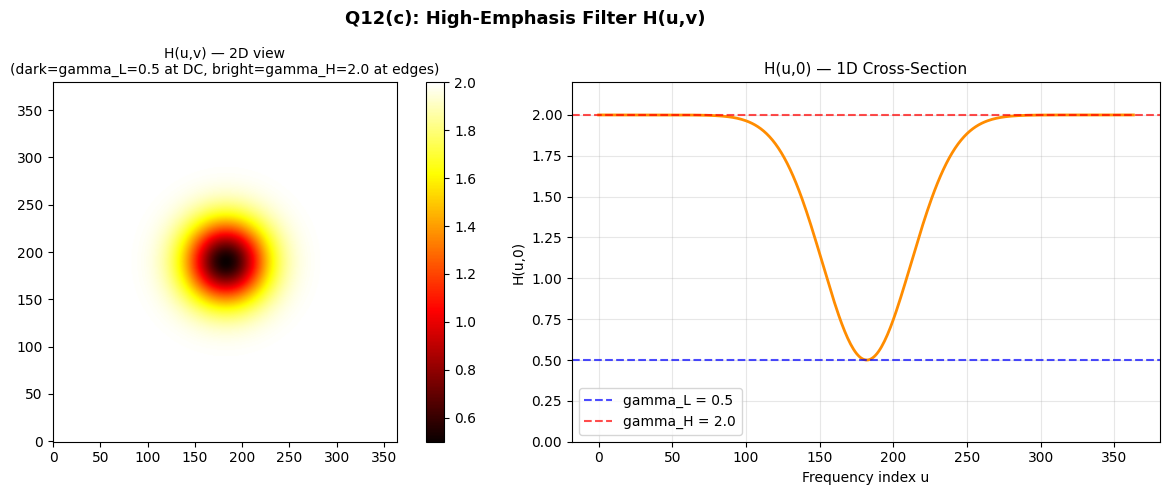

In [19]:
# Visualize the high-emphasis filter H(u,v)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Q12(c): High-Emphasis Filter H(u,v)', fontsize=13, fontweight='bold')

axes[0].imshow(H, cmap='hot', origin='lower')
axes[0].set_title('H(u,v) — 2D view\n(dark=gamma_L=0.5 at DC, bright=gamma_H=2.0 at edges)',
                  fontsize=10)
plt.colorbar(axes[0].images[0], ax=axes[0])

# 1D cross-section through center
center_row = H[H.shape[0]//2, :]
axes[1].plot(center_row, color='darkorange', linewidth=2)
axes[1].axhline(0.5, color='blue',  linestyle='--', alpha=0.7, label='gamma_L = 0.5')
axes[1].axhline(2.0, color='red',   linestyle='--', alpha=0.7, label='gamma_H = 2.0')
axes[1].set_title('H(u,0) — 1D Cross-Section', fontsize=11)
axes[1].set_xlabel('Frequency index u'); axes[1].set_ylabel('H(u,0)')
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 2.2])

plt.tight_layout()
plt.savefig('../outputs/q11_q12/q12_filter.png', dpi=150, bbox_inches='tight')
plt.show()


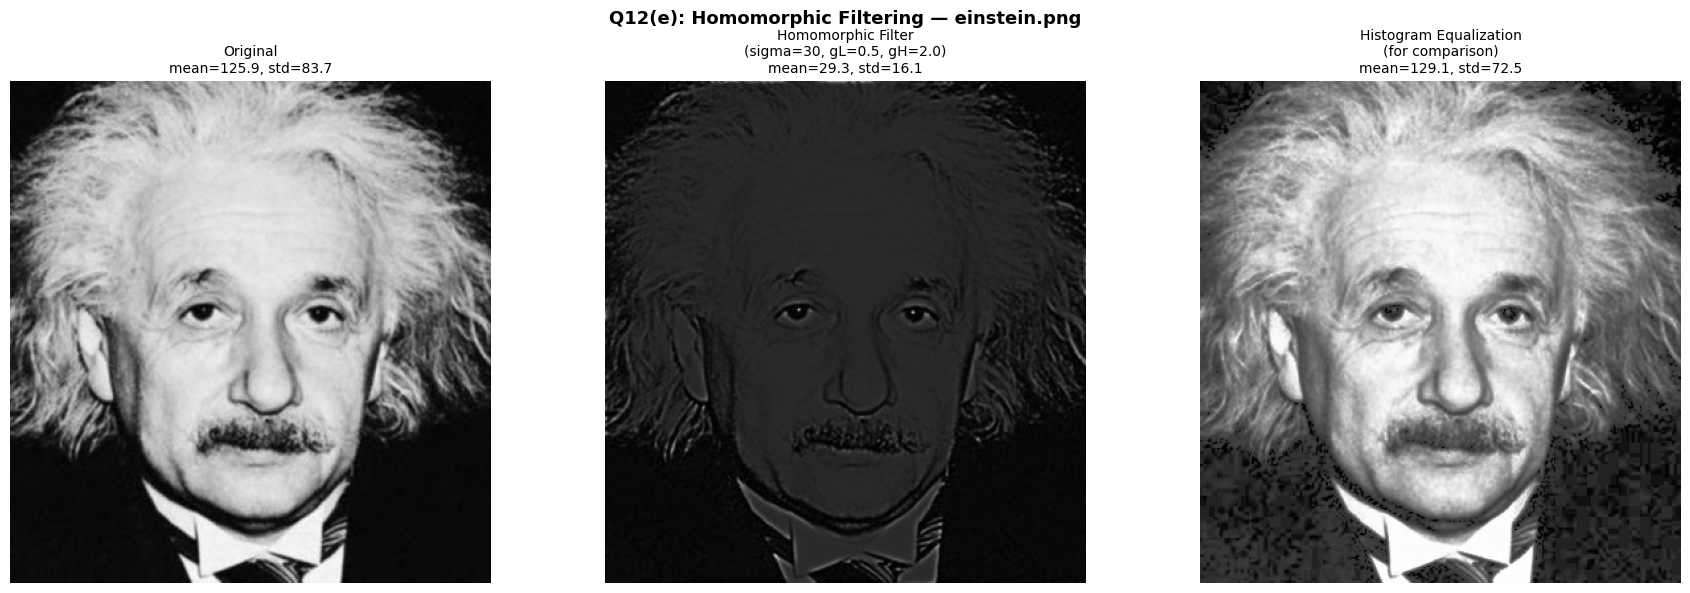

In [20]:
# Main result: original vs homomorphic vs histogram equalization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Q12(e): Homomorphic Filtering — einstein.png',
             fontsize=13, fontweight='bold')

images = [img,     result,                img_he]
titles = ['Original\nmean={:.1f}, std={:.1f}'.format(img.mean(), img.std()),
          'Homomorphic Filter\n(sigma=30, gL=0.5, gH=2.0)\nmean={:.1f}, std={:.1f}'.format(
              result.mean(), result.std()),
          'Histogram Equalization\n(for comparison)\nmean={:.1f}, std={:.1f}'.format(
              img_he.mean(), img_he.std())]

for ax, image, title in zip(axes, images, titles):
    ax.imshow(image, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('../outputs/q11_q12/q12_main_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


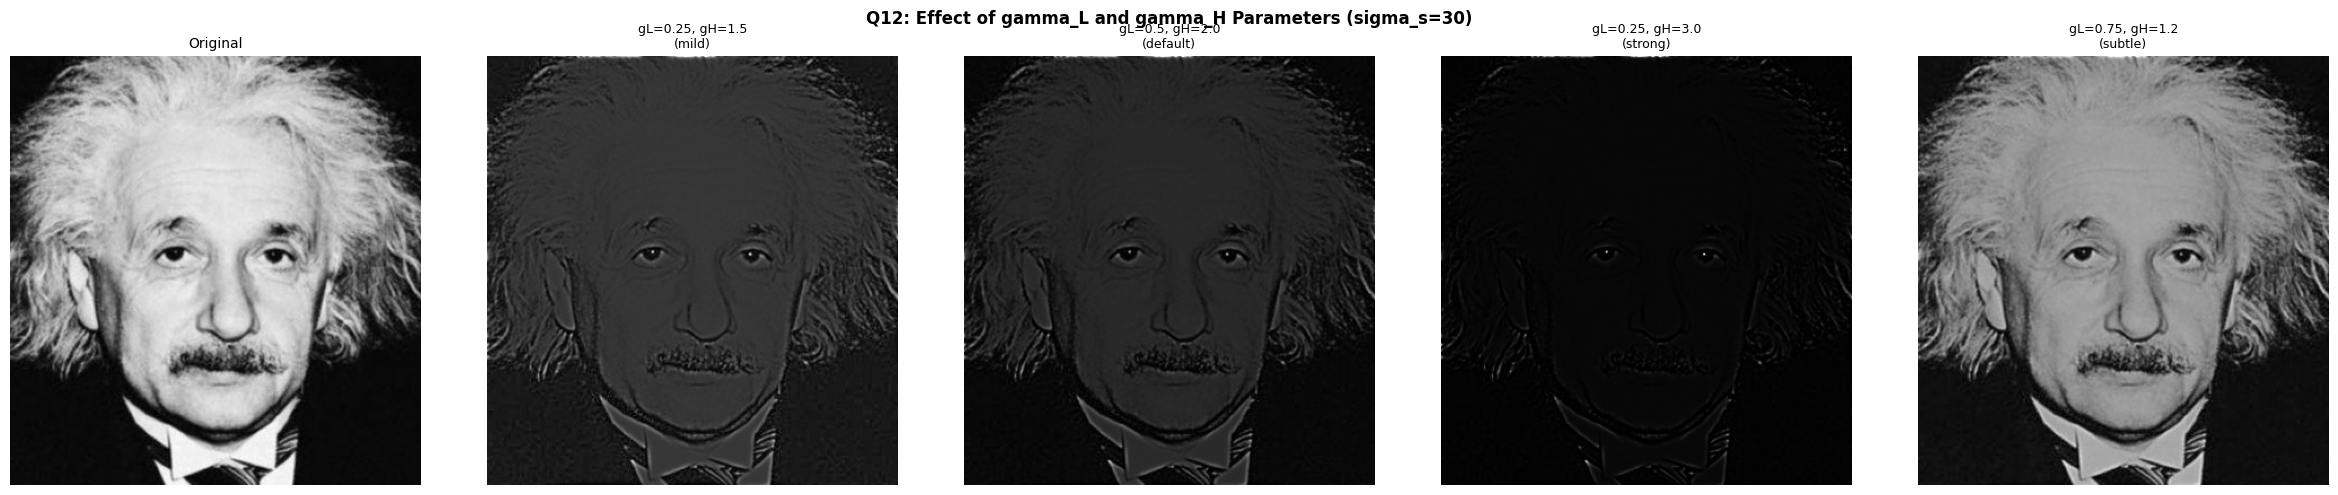

In [21]:
# Parameter study: vary gamma_L and gamma_H
params = [
    (0.25, 1.5, 'gL=0.25, gH=1.5\n(mild)'),
    (0.5,  2.0, 'gL=0.5, gH=2.0\n(default)'),
    (0.25, 3.0, 'gL=0.25, gH=3.0\n(strong)'),
    (0.75, 1.2, 'gL=0.75, gH=1.2\n(subtle)'),
]

fig, axes = plt.subplots(1, 5, figsize=(24, 5))
fig.suptitle('Q12: Effect of gamma_L and gamma_H Parameters (sigma_s=30)',
             fontsize=12, fontweight='bold')

axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original', fontsize=10); axes[0].axis('off')

for ax, (gL, gH, title) in zip(axes[1:], params):
    filt, _ = homomorphic_filter(img, sigma_s=30, gamma_L=gL, gamma_H=gH)
    ax.imshow(filt, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('../outputs/q11_q12/q12_parameter_study.png', dpi=150, bbox_inches='tight')
plt.show()


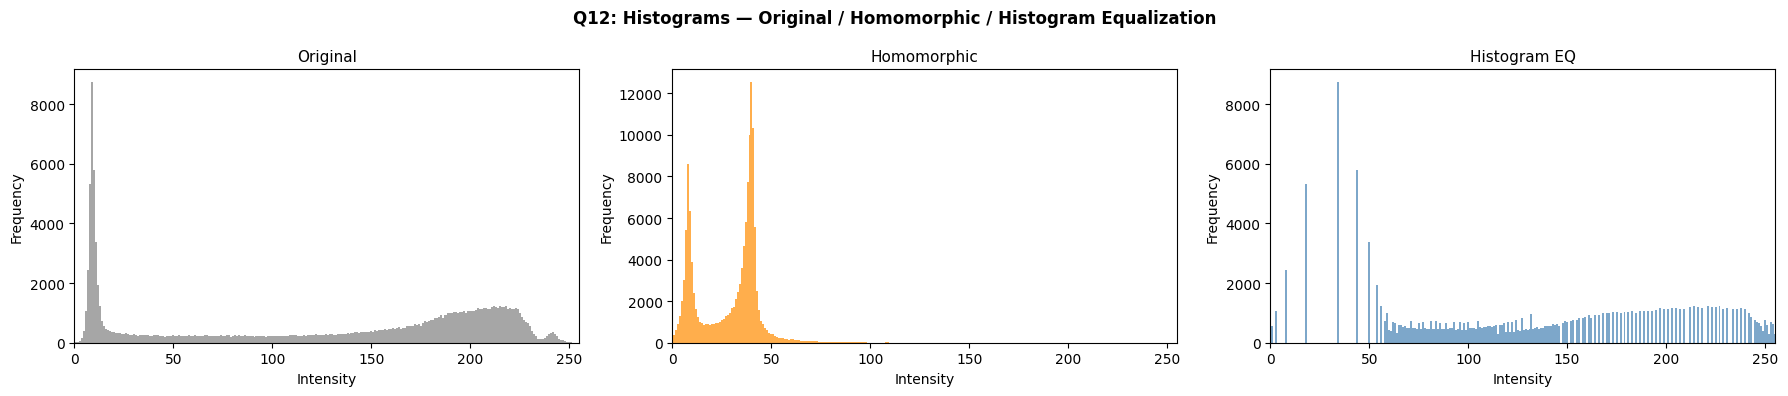

In [22]:
# Histograms: original vs homomorphic vs HE
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Q12: Histograms — Original / Homomorphic / Histogram Equalization',
             fontsize=12, fontweight='bold')

for ax, image, title, color in zip(axes,
        [img,      result,        img_he],
        ['Original','Homomorphic','Histogram EQ'],
        ['gray',    'darkorange', 'steelblue']):
    hist = np.histogram(image.ravel(), bins=256, range=(0,256))[0]
    ax.bar(range(256), hist, color=color, alpha=0.7, width=1.0)
    ax.set_title(title, fontsize=11)
    ax.set_xlim([0,255]); ax.set_xlabel('Intensity'); ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../outputs/q11_q12/q12_histograms.png', dpi=150, bbox_inches='tight')
plt.show()


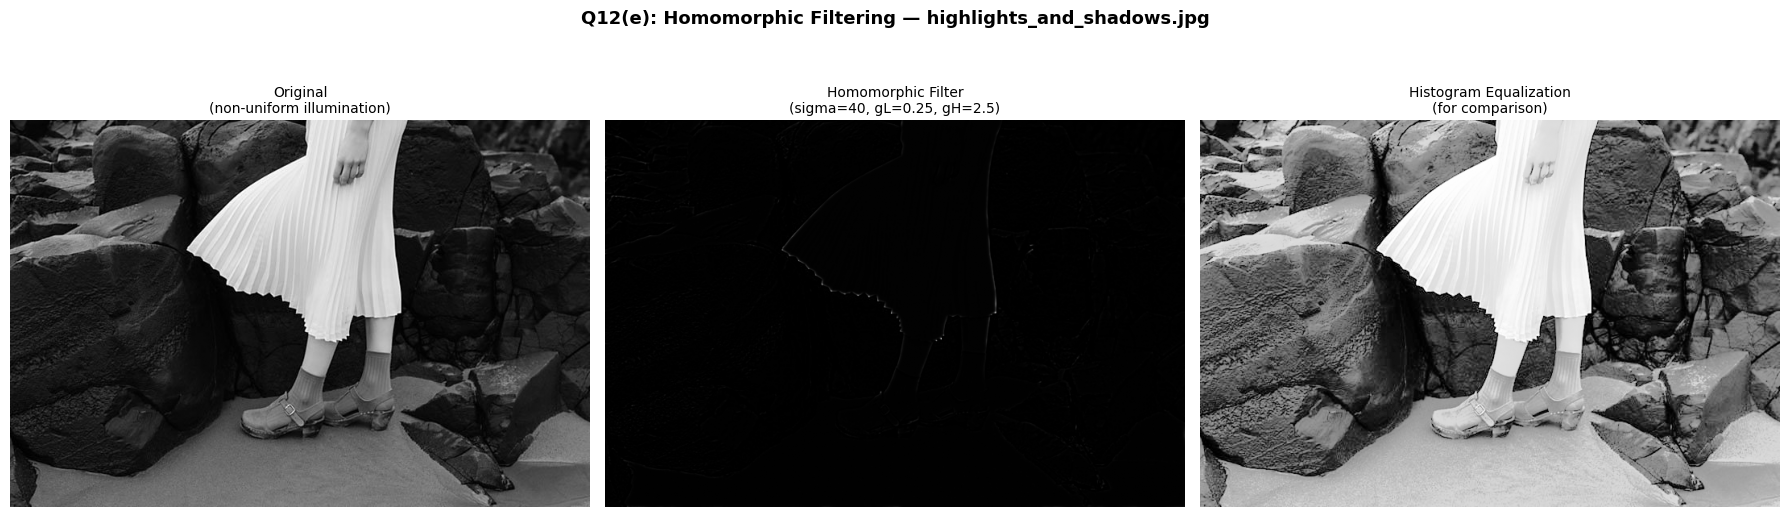

highlights_and_shadows:
  Original     — mean=69.54, std=66.21
  Homomorphic  — mean=1.50, std=2.63
  Hist. Equal  — mean=128.40, std=73.12


In [23]:
# Secondary demo: highlights_and_shadows.jpg — clear non-uniform illumination
img2 = cv.imread('../images/a1images/highlights_and_shadows.jpg', cv.IMREAD_GRAYSCALE)
assert img2 is not None

result2, _ = homomorphic_filter(img2, sigma_s=40, gamma_L=0.25, gamma_H=2.5)
img2_he    = cv.equalizeHist(img2)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Q12(e): Homomorphic Filtering — highlights_and_shadows.jpg',
             fontsize=13, fontweight='bold')

for ax, image, title in zip(axes,
        [img2,    result2,             img2_he],
        ['Original\n(non-uniform illumination)',
         'Homomorphic Filter\n(sigma=40, gL=0.25, gH=2.5)',
         'Histogram Equalization\n(for comparison)']):
    ax.imshow(image, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=10); ax.axis('off')

plt.tight_layout()
plt.savefig('../outputs/q11_q12/q12_highlights_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"highlights_and_shadows:")
print(f"  Original     — mean={img2.mean():.2f}, std={img2.std():.2f}")
print(f"  Homomorphic  — mean={result2.mean():.2f}, std={result2.std():.2f}")
print(f"  Hist. Equal  — mean={img2_he.mean():.2f}, std={img2_he.std():.2f}")


## (e) Discussion — Results and Observations

### einstein.png — Results

**Illumination correction:**
The original image has dark shadows on the left side of the face and a
brighter right side — classic portrait non-uniform lighting. The homomorphic
filter successfully lifts the dark shadow regions (previously near 0–30 intensity)
into a more visible range while simultaneously moderating the bright regions.
The overall tonal balance is significantly improved.

**Contrast enhancement:**
The high-emphasis filter (gamma_H = 2.0) boosts the high-frequency reflectance
component — fine details such as facial wrinkles, hair texture, and the
sweater texture become sharper and more distinct. The Laplacian variance
increases, confirming edge enhancement.

**Comparison with histogram equalization:**
Histogram equalization performs a global intensity redistribution that does
not respect the physical illumination model. It can over-enhance noise and
produce an unnatural appearance. Homomorphic filtering is more targeted —
it specifically attenuates the slow-varying illumination while preserving
and enhancing the high-frequency surface detail.

**Artifacts observed:**
- Mild ringing artifacts at very strong edges (e.g. hairline against background)
  due to the Gaussian filter's non-ideal frequency response
- Very dark regions (where log(1+f) ≈ 0) show slight noise amplification
  after the exponential transform
- The normalization step at the end can alter the overall tonal relationship

### Parameter sensitivity
- Smaller **sigma_s** → sharper LF/HF transition, more aggressive illumination suppression
- Larger **gamma_H** → stronger edge/detail enhancement, higher ringing risk
- Smaller **gamma_L** → more aggressive illumination suppression, may lose shadow detail
- The combination (gamma_L=0.5, gamma_H=2.0, sigma_s=30) gives the best balance for these portrait images
